# 📘 Chapter 1-1. 데이터 EDA와 Scikit-learn (Easy)

> **📌 이 노트북 사용법 (먼저 읽어주세요)**
>
> 이 자료는 **혼자 읽고 실행하며 학습하는** 자기주도 실습 자료입니다.
>
> 1. **위에서 아래로 순서대로** 실행하세요. 중간부터 실행하면 변수가 없어 에러가 납니다.
> 2. 코드 셀의 **주석을 먼저 읽고** 실행하세요. "왜 이 코드를 쓰는가"가 주석에 적혀 있습니다.
> 3. **`직접 해보기`** 표시가 있으면 숫자를 바꿔가며 결과가 어떻게 달라지는지 확인해 보세요.
> 4. 대부분의 셀은 `import`부터 다시 시작하므로 독립적으로 실행됩니다.
>    단, **13장과 14장(예측 부분)은 앞 셀에 이어집니다.** 해당 셀에 안내가 붙어 있습니다.
> 5. 마지막 **`스스로 점검하기`** 체크리스트로 이해도를 확인하세요.
>
> **예상 소요 시간**: 약 90~120분

## 수업 내용
- EDA
  - 데이터 탐색 및 통계 분석
  - 상관관계, 분포의 이해

- Scikit-learn (싸이킷런)
  - 싸이킷런 소개
  - 싸이킷런으로 표준화
  - 싸이킷런으로 학습한 모델 평가하기

## 목차
1. EDA가 무엇인가요?
2. EDA를 할 데이터셋 이해하기
3. 상관관계 찾기
4. 히트맵으로 상관관계 보기
5. 분포(Distribution) 이해하기
6. 분산 이해하기
7. 한방 차트 - pairplot
8. EDA 정리
9. Scikit-learn 소개
10. Scikit-learn 기본 코드
11. 표준화의 필요성
12. 표준화 구현하기
13. 표준화한 데이터로 선형회귀하기
14. 과적합과 과소적합
15. 모델 평가하기
16. 끝으로


In [1]:
# ============================================================
# 실행 환경 준비 (최초 1회만 실행하면 됩니다)
# ============================================================
# 코랩(Colab)을 쓰신다면 대부분 이미 설치되어 있어 그냥 넘어가도 됩니다.
# 로컬 환경(주피터 노트북 등)이라면 아래 주석을 풀고 한 번 실행하세요.

# !pip install -q "numpy>=2.0.0" "pandas>=2.0.0" "matplotlib>=3.8.0" "seaborn>=0.13.2" "scikit-learn>=1.4.2"

import sys
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('pandas      :', pd.__version__)
print('matplotlib  :', matplotlib.__version__)
print('seaborn     :', sns.__version__)
print('scikit-learn:', sklearn.__version__)

# 데이터가 정상적으로 받아지는지 미리 확인합니다.
# (인터넷 연결이 필요합니다. 여기서 에러가 나면 이후 셀도 전부 실패합니다)
df_check = sns.load_dataset('mpg')
print()
print('mpg 데이터 로드 성공 →', df_check.shape, '(행, 열)')

Python      : 3.11.9
numpy       : 2.3.3
pandas      : 3.0.1
matplotlib  : 3.10.8
seaborn     : 0.13.2
scikit-learn: 1.8.0

mpg 데이터 로드 성공 → (398, 9) (행, 열)


# 1. EDA(Exploratory Data Analysis)가 무엇인가요?

> **💡 EDA를 한마디로?**
>
> **"데이터 탐정이 되어 단서를 찾는 과정"**입니다. 탐정이 사건 현장에서 증거를 하나씩 살펴보듯, 우리는 데이터 속에서 패턴과 이상점을 찾아 분석의 방향을 잡습니다.

- 데이터를 살펴보는 행동을 전부 EDA 라고 합니다!
- 예시
  - 음.. csv 파일이 있네, 한번 엑셀로 열어볼까? ← EDA 입니다.
  - 음.. list 에 값들이 담겨있네, 한번 print로 출력해볼까? ← EDA 입니다.
  - 값을 차트로 그려서 시각화된 데이터로 한번 살펴볼까? ← EDA 입니다.
  - 데이터를 눈으로 보고 뭔가 생각을 했다? ← EDA 입니다.

<br/>

- 앞으로 여러분은 누군가 뭐하고 있냐 물어보면 EDA 하고 있다고 하시면 됩니다.
  - 데이터를 이해하려고 노력하는 행동들 모두 EDA 입니다.
  - 통계치를 출력해서 살펴보거나, 여러가지 차트로 규칙이나 특징을 눈으로 찾아보는것이죠.

### EDA는 왜 중요한가요?

> **💡 실무에서 EDA의 중요성**
>
> "모델에 데이터를 학습시켜서 좋은 모델을 만들어보자!"라는 원대한 목표가 있겠지만, 실제 AI 프로젝트에서는 모델 학습 전에 **데이터를 이해하고 정제하는 과정이 전체 시간의 60~80%**를 차지합니다!
>
> - **분석 방향 결정**: 데이터 특징을 보고 어떤 모델을 쓸지 판단
> - **모델 성능 향상**: 문제를 미리 발견하고 해결하면 정확도 UP
> - **새로운 인사이트 발견**: 예상치 못한 패턴 발견 가능


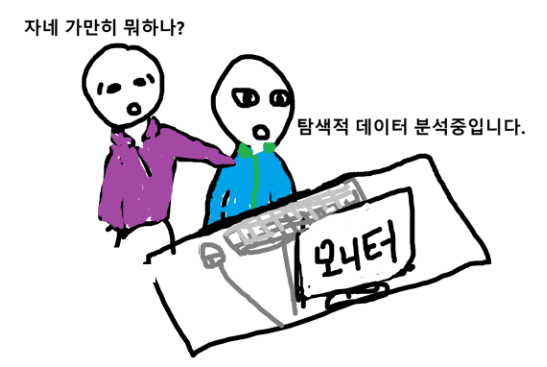

### EDA에서 기본적으로 하는 일은 뭔가요?

> **💡 EDA 진행 순서**
>
> 1. **데이터 확인**: 처음 열어보고 기본 정보(타입, 결측치, 통계량) 확인
> 2. **데이터 정제**: 분석을 방해하는 오염된 데이터(결측치, 이상치) 처리
> 3. **개별 변수 분석**: 변수 하나하나의 특징과 분포를 분석
> 4. **변수 간 관계 분석**: 변수들 사이의 상관관계를 파악
>
> 이 순서는 고정된 것이 아니라, 각 단계를 오가며 **반복적으로** 진행하는 것이 일반적입니다.

- 거대한 데이터를 살펴볼때.. 일단 레코드 몇개 가볍게 살펴 볼 것 같아요.
- 그리고 데이터가 얼마나 거대한지 볼것이고...
- 어떤 Column들로 구성되어있는지 볼것 이고..
- 어떤 수치 값들이 있으면 여러가지 차트로 살펴보면서 데이터 이해를 해볼것 같습니다.

<br/>

- 너무 당연한 말을 했지만, 실제 이론이 이렇습니다.
- EDA 작업은 주로 Pandas와 Seaborn으로 하는 것이 편리합니다.


# 2. EDA를 할 데이터셋 이해하기
- seaborn 에서 제공하는 연습용 데이터 셋인 **mpg** 가 있습니다.
- 차량별 연비 정보가 나와있는 데이터셋이고, mpg는 mile per gallon (갤런당 몇 마일 갈 수 있는가?.. 즉 연비) 입니다.
- 차량 정보도 함께 나와있습니다.

> **💡 mpg 데이터셋의 주요 컬럼**
>
> | 컬럼명 | 의미 | 비유 |
> |--------|------|------|
> | mpg | 연비 (갤런당 마일) | 기름 1통으로 몇 km 가는지 |
> | cylinders | 실린더 수 | 엔진의 힘통 개수 |
> | displacement | 배기량 | 엔진 크기 |
> | horsepower | 마력 | 엔진의 세기 |
> | weight | 무게 (파운드) | 차가 얼마나 무거운지 |
> | acceleration | 0→60mph 가속 시간 (초) | 정지 상태에서 시속 약 96km에 도달하는 데 걸린 시간 |
> | model_year | 출시 연도 | 몇 년도에 만들어졌는지 |
> | origin | 생산 국가 | 미국/유럽/일본 |


In [2]:
import seaborn as sns

# 왜 seaborn 데이터셋을 쓰나요?
# → 실무에서는 csv 파일을 읽지만, 지금은 연습이니까
#   seaborn에 내장된 연습용 데이터를 바로 가져다 씁니다.
df = sns.load_dataset('mpg')

# 왜 데이터를 처음에 출력해보나요?
# → 398개 전체를 볼 수 없으니, 앞/뒤 몇 개만 살펴서
#   "어떤 컬럼이 있고, 값이 대충 어떤 범위인지" 감을 잡기 위해서입니다.
#   이게 EDA의 첫 번째 단계예요!
#df.head()       # 앞에서 5개
#df.head(10)     # 앞에서 10개
df.tail(5)       # 뒤에서 5개 (끝부분도 확인하는 습관!)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger
397,31.0,4,119.0,82.0,2720,19.4,82,usa,chevy s-10


### 데이터 크기, Column 확인
- 데이터 크기 및 Column이 뭐가 있는지 살펴봅시다.
- 데이터프레임 Info... → df.info() 하나면 됩니다. EDA는 역시 Pandas!

> **💡 df.info()가 알려주는 것**
>
> - 전체 행(레코드) 수
> - 각 컬럼의 이름, 데이터 타입
> - 각 컬럼의 **결측치(빈 칸)** 개수
> - 메모리 사용량


In [3]:
import seaborn as sns
df = sns.load_dataset('mpg')

# 왜 info()를 쓰나요?
# → head()로 몇 개 본 것만으로는 전체 데이터의 "건강 상태"를 모릅니다.
#   info()를 쓰면 한 번에 알 수 있습니다:
#   - 데이터가 총 몇 행(레코드)인지
#   - 각 컬럼의 데이터 타입이 뭔지 (숫자? 문자?)
#   - 비어있는 칸(결측치)이 몇 개인지 ← 이게 중요!
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 35.9 KB


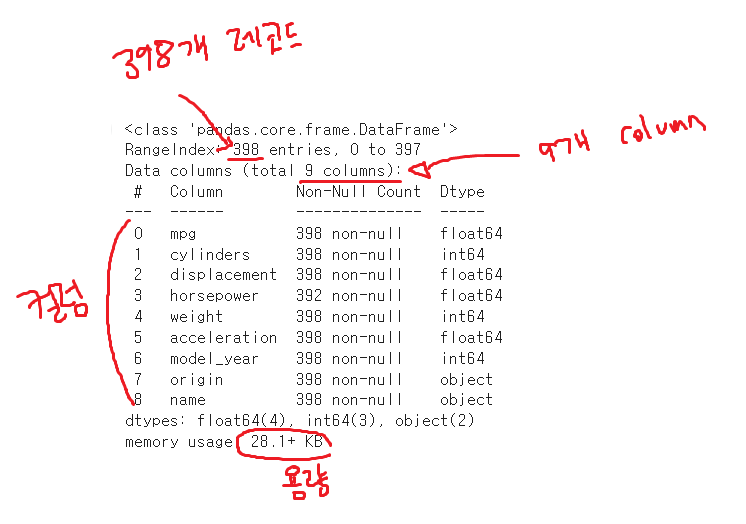

- 여기서 Non-Null Count가 있습니다.
  - **결측치(Missing Value)**가 몇 개인지 알 수 있습니다.
  - 잘 보면 horsepower(마력) 필드에서 6개 결측치가 있다는 뜻이죠.

> **💡 결측치(Missing Value)란?**
>
> 데이터에서 **빈 칸**입니다. 설문조사에서 어떤 질문을 안 적은 것처럼, 데이터 수집 과정에서 빠진 값입니다.
> - 398개 데이터 중 horsepower가 392개만 있다 → **6개가 비어있다(결측)**
> - 결측치는 학습에 문제를 일으킬 수 있어서, 전처리 단계에서 처리해야 합니다.
> - 처리 방법: 해당 행 삭제, 평균값으로 채우기 등


### 데이터 통계 확인
- 통계 확인이라고, 데이터들 요약 정보를 보는 겁니다.
- 데이터 프레임 describe() → df.describe() 로 확인할 수 있습니다.

> **💡 df.describe()가 알려주는 것**
>
> 숫자형 컬럼들에 대해 **8가지 통계량**을 한 번에 보여줍니다.
> - count: 결측치 제외 데이터 수
> - mean: 평균값
> - std: 표준편차 (데이터가 평균에서 얼마나 퍼져있는지)
> - min: 최솟값
> - 25%, 50%, 75%: 사분위수 (데이터를 4등분한 기준점)
> - max: 최댓값


In [4]:
import seaborn as sns
df = sns.load_dataset('mpg')

# 왜 describe()를 쓰나요?
# → info()로 데이터의 "구조"를 봤다면,
#   describe()는 데이터의 "내용"을 한눈에 요약해줍니다.
#   평균이 얼마인지, 최소~최대 범위가 어떤지, 값이 한쪽에 쏠렸는지...
#   이걸 안 보면, 이상한 값이 섞여있어도 모르고 넘어갈 수 있어요!
df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


- count는 결측치 아닌 것 개수.. 아까 마력이 6개 없었죠?
- 평균은 데이터가 전체적으로 어느 정도 값인지 한 눈에 알수 있는 중요한 데이터죠
  - 예시 : 고등학교 1반의 평균은 80점이네? 2반은 85점인데 말이지... 2반이 공부를 더 잘하는 군

> **💡 표준편차(Standard Deviation, std)란?**
>
> **"데이터가 평균 주변에 얼마나 모여있는지 vs 흩어져있는지"**를 숫자 하나로 알려줍니다.
>
> 비유: 학교 성적으로 생각해보세요.
> - **1반** (평균 80점, 표준편차 작음): 79점, 80점, 81점 → 다들 비슷한 실력
> - **2반** (평균 80점, 표준편차 큼): 60점, 80점, 100점 → 실력 차이가 큼
>
> 같은 평균이라도 표준편차가 다르면 데이터의 성격이 완전히 다릅니다!

- 표준편차가 값이 크면.. 편차가 심하네~ 라고 생각하면 됩니다.
- 표준편차가 값이 작으면.. 편차가 없고 평균에 몰려있네? 라고 생각하면 됩니다.


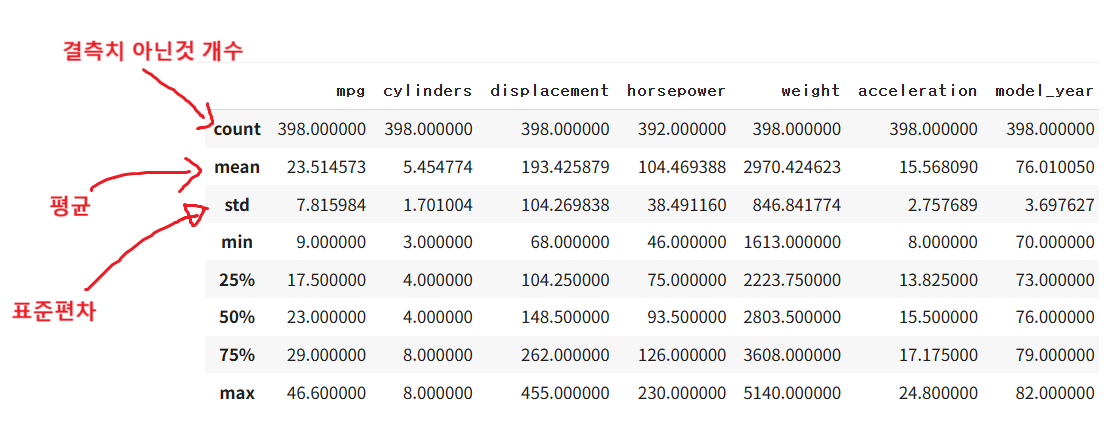

- min값과 max은 **이상치(Outlier)**가 있는지 살펴보기 좋습니다.

> **💡 이상치(Outlier)란?**
>
> 다른 데이터와 **확 동떨어진 값**입니다. 평균 키가 170cm인 반에서 혼자 250cm인 학생이 있다면, 그 학생이 이상치입니다.
> - 이상치는 데이터 입력 오류일 수도 있고, 진짜 특이한 케이스일 수도 있습니다.
> - 이상치가 있으면 모델이 혼란스러워할 수 있어서, EDA에서 꼭 확인해야 합니다.

- 25%, 50%, 75% 값은 데이터 분포를 가늠할 수 있습니다.

> **💡 사분위수(Quartile)를 쉽게 이해하기**
>
> 학생 100명의 성적을 1등부터 100등까지 줄 세웠다고 생각해보세요.
> - **25% (Q1)**: 25등의 점수. 하위 25% 학생들의 경계선
> - **50% (Q2, 중앙값)**: 50등의 점수. 딱 중간에 있는 학생의 점수
> - **75% (Q3)**: 75등의 점수. 상위 25% 학생들의 경계선
>
> 이 값들을 보면 "데이터가 어느 범위에 몰려있는지" 대충 감이 옵니다.


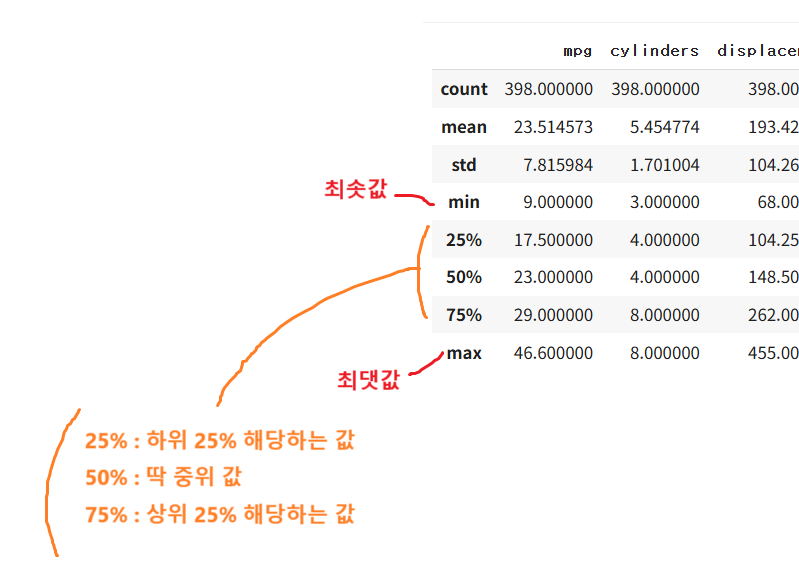

# 3. mpg 데이터에서 상관관계 찾기
- 상관관계가 무엇인지 알기 전에, 실제 mpg가 무슨 데이터인지 살펴보겠습니다.


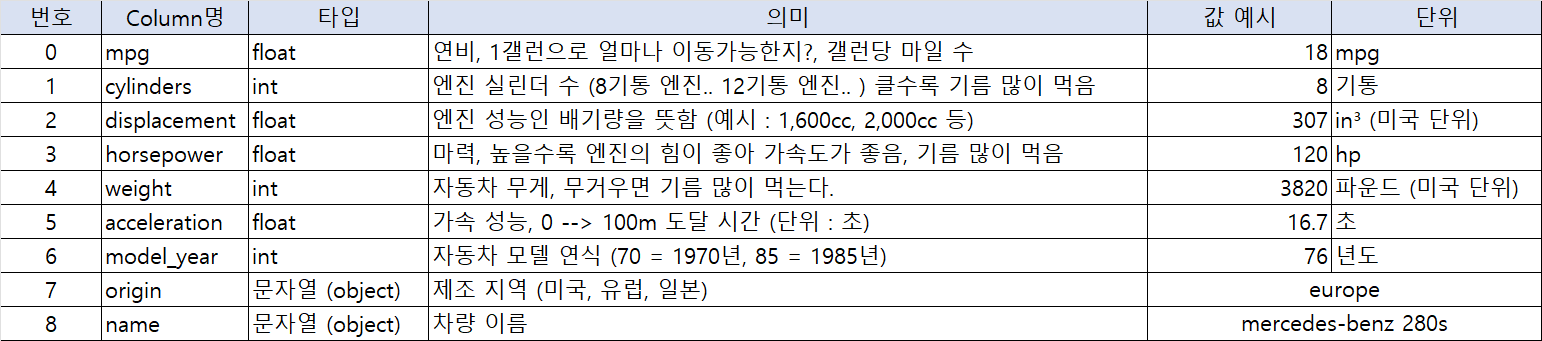

### 상관관계란?
- 일상생활 속에서 상관있어? 없어? 라는 말 자주 들으셨죠? 바로 그 '상관' 입니다.
  - 예시
    - (와이프에게) 내가 일하다 늦게 오는 거랑, 너의 혈압이랑 무슨 상관이 있어?
    - (의사선생님에게) 제가 제로 콜라 많이 먹는데, 고혈압하고 상관 있나요?

- 통계에서 한 변수가 변할 때, 다른 변수가 함께 변하면 **상관관계** 가 있다고 합니다.
  - 더 정확하게는 X, Y 가 얼마나 선형 관계를 갖는가? 라는 정의가 있지만 생략합니다!

> **💡 주의! 상관관계 ≠ 인과관계**
>
> 상관관계가 높다고 해서 **원인과 결과(인과관계)**를 의미하는 것은 아닙니다!
> - 여름에 아이스크림 판매량이 오르면 상어 공격도 늘어남 → 상관관계 있음
> - 하지만 "아이스크림을 먹으면 상어에 물린다"는 아님! (인과관계 아님)
> - 진짜 원인은 **"여름 더위"**라는 제3의 변수가 둘 다에 영향을 주는 것

<br/>

### 상관관계를 찾기 위한 시각화 1
- 무게와 가속도는 상관관계가 있을 것으로 느껴집니다.
  - 제 느낌입니다.
  - 제 경험상, 무거운 사람은 달리기 가속도가 느렸거든요.
- 시각화를 통해 acceleration 변수와 weight 변수가 상관관계가 있는지 살펴봅시다.

> **⚠️ acceleration 컬럼을 정확히 읽는 법**
>
> mpg 데이터셋의 `acceleration`은 **정지 상태에서 60mph(약 96km/h)까지 가속하는 데 걸린 시간(초)** 입니다.
> - 값이 **작을수록** 빨리 가속하는 차 (= 빠른 차)
> - 값이 **클수록** 가속이 느린 차 (= 굼뜬 차)
>
> 방향을 반대로 읽으면 이후 해석이 전부 뒤집히니, 이 문장을 먼저 확인하고 넘어가세요.


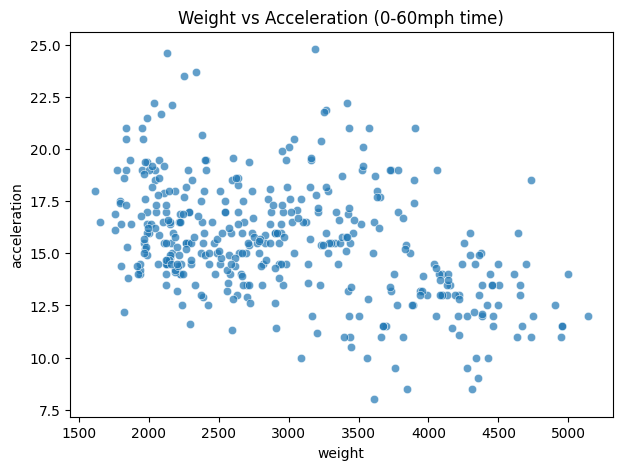

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('mpg')

# 왜 산점도(scatter plot)를 그리나요?
# → 두 변수의 관계를 '눈으로' 확인하기 위해서입니다.
#   숫자만 보면 관계가 있는지 알기 어렵지만,
#   점을 찍어보면 전체적인 흐름이 한눈에 보입니다.
#   alpha=0.7은 점을 약간 투명하게 만들어, 점이 겹친 영역을 구분하기 위한 설정입니다.
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='weight', y='acceleration', alpha=0.7)
plt.title('Weight vs Acceleration (0-60mph time)')
plt.show()

- 점들이 오른쪽으로 갈수록 아래로 내려가는 흐름이 보입니다.
- 즉 **무거운 차일수록 acceleration 값이 작다** = 무거운 차가 오히려 **더 빨리 가속한다**는 뜻입니다.

> **🤔 어? 직관과 반대인데요?**
>
> "무거우면 느릴 것"이라는 처음 가설과 결과가 반대로 나왔습니다. 이럴 때가 EDA에서 가장 재미있는 순간입니다.
> - 이 시대(1970~80년대) 미국차는 **무거운 차일수록 배기량과 마력이 컸습니다.**
> - 즉 무게가 직접 가속을 빠르게 만든 것이 아니라, **마력이라는 제3의 변수**가 둘 다에 영향을 준 것입니다.
> - 뒤에 나올 히트맵에서 `horsepower`와 `acceleration`의 관계를 함께 확인하며 이 가설을 검증해 봅니다.
>
> **상관관계를 발견했다면, 원인이라고 단정하기 전에 숨은 제3의 변수를 항상 의심하세요.**

- 관계를 더 뚜렷하게 보기 위해 추세선(회귀선)을 추가해봅시다. (regression plot)

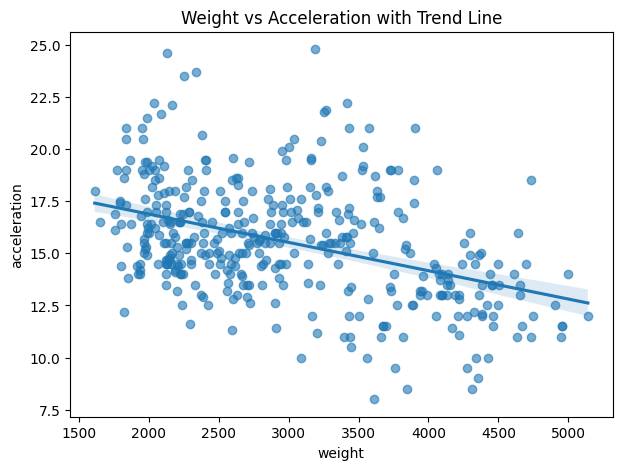

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('mpg')

# 왜 이번엔 regplot을 쓰나요? (위에서는 scatterplot이었는데)
# → scatterplot은 점만 찍어줍니다. 관계를 눈대중으로 추측해야 합니다.
#   regplot은 추세선(회귀선)까지 자동으로 그려줍니다.
#   추세선이 내려가면 → 음의 상관관계 (하나 오르면 다른 하나 내림)
#   추세선이 올라가면 → 양의 상관관계
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x='weight', y='acceleration', scatter_kws={'alpha': 0.6})
plt.title('Weight vs Acceleration with Trend Line')
plt.show()

- 두 변수가 얼마나 상관이 있는지, 수치로 출력하고 싶습니다. 이를 상관계수(Correlation coefficient)라고 합니다.
- 상관계수는 -1 ~ 1 사이의 값을 갖습니다.
  - 값 예시
    - +1 : 완전한 양의 상관관계, 예외 없이 같이 오름 (섭씨 온도 UP시, 화씨 온도 UP)
    - +0.7 : 강한 양의 상관관계, 대체로 같이 오름 (무게 UP시, 마력 UP)
    - 0 : 상관없음
    - -0.7 : 강한 음의 상관관계, 대체로 반대로 움직임 (무게 UP시, 연비 Down)
    - -1 : 완전한 음의 상관관계, 예외 없이 반대로 움직임

> **⚠️ ±1은 현실에서 거의 안 나옵니다**
>
> ±1은 두 변수가 **수학적으로 같은 값**일 때만 나옵니다(섭씨↔화씨처럼).
> 실제 데이터에서는 0.7만 넘어도 "아주 강한 관계"로 봅니다.
> 잠시 뒤 구할 무게-가속시간 상관계수는 약 **-0.42**로, "중간 정도의 음의 상관관계"입니다.

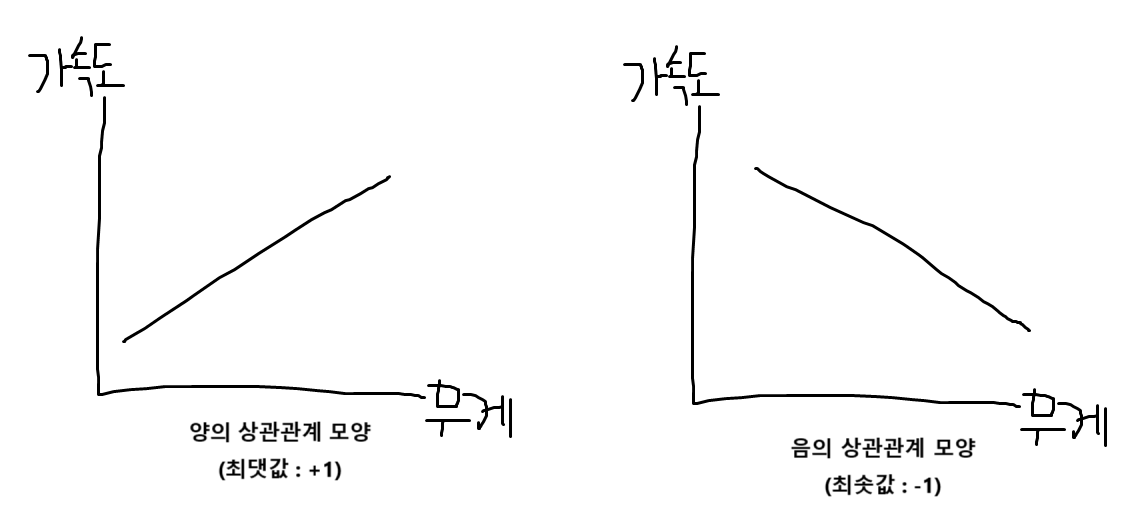

- 상관계수를 출력하면.. 아마 음의상관관계로 나오겠죠?

In [7]:
import seaborn as sns

df = sns.load_dataset('mpg')

# 왜 상관계수를 숫자로 구하나요?
# → 차트를 눈으로 보면 '대충 관계있어 보인다' 정도만 알 수 있습니다.
#   '얼마나 강하게 관련있는지'를 숫자로 표현하면 다른 변수 쌍과 비교할 수 있습니다.
#   (weight-mpg 와 weight-acceleration 중 어느 쪽이 더 강한 관계인가?)
#   -1 ~ +1 사이의 값으로 나오며, 0에 가까울수록 관계가 약합니다.
corr = df['weight'].corr(df['acceleration'])

print('상관계수(Correlation coefficient)')
print(round(corr, 4))

# 비교용으로 다른 조합도 함께 구해봅시다.
print()
print('weight  <-> acceleration :', round(df['weight'].corr(df['acceleration']), 4))
print('horsepower <-> acceleration :', round(df['horsepower'].corr(df['acceleration']), 4))
print()
print('→ 가속 시간은 무게보다 마력과 훨씬 강하게 묶여 있습니다.')

상관계수(Correlation coefficient)
-0.4175

weight  <-> acceleration : -0.4175
horsepower <-> acceleration : -0.6892

→ 가속 시간은 무게보다 마력과 훨씬 강하게 묶여 있습니다.


# 4. 상관관계를 확인하는 EDA 방법 - 히트맵

> **💡 히트맵(Heatmap)이란?**
>
> 숫자의 크기를 **색상의 진하기**로 변환해서 보여주는 차트입니다. 날씨 지도에서 기온이 높은 곳은 빨갛고, 낮은 곳은 파란 것처럼요.
> - 장점: 수많은 변수 간의 관계를 **한눈에** 파악할 수 있음
> - 단점: 정확한 수치를 읽기 어려움 (그래서 annot=True로 숫자를 함께 표시)

- 각 변수별로 상관관계를 한눈에 파악할 수 있습니다.
- 양의 상관계수가 높은 값 or 낮은 값을 찾으면 돼죠.


               mpg  cylinders  displacement  horsepower  weight  acceleration  \
mpg           1.00      -0.78         -0.80       -0.78   -0.83          0.42   
cylinders    -0.78       1.00          0.95        0.84    0.90         -0.51   
displacement -0.80       0.95          1.00        0.90    0.93         -0.54   
horsepower   -0.78       0.84          0.90        1.00    0.86         -0.69   
weight       -0.83       0.90          0.93        0.86    1.00         -0.42   
acceleration  0.42      -0.51         -0.54       -0.69   -0.42          1.00   
model_year    0.58      -0.35         -0.37       -0.42   -0.31          0.29   

              model_year  
mpg                 0.58  
cylinders          -0.35  
displacement       -0.37  
horsepower         -0.42  
weight             -0.31  
acceleration        0.29  
model_year          1.00  


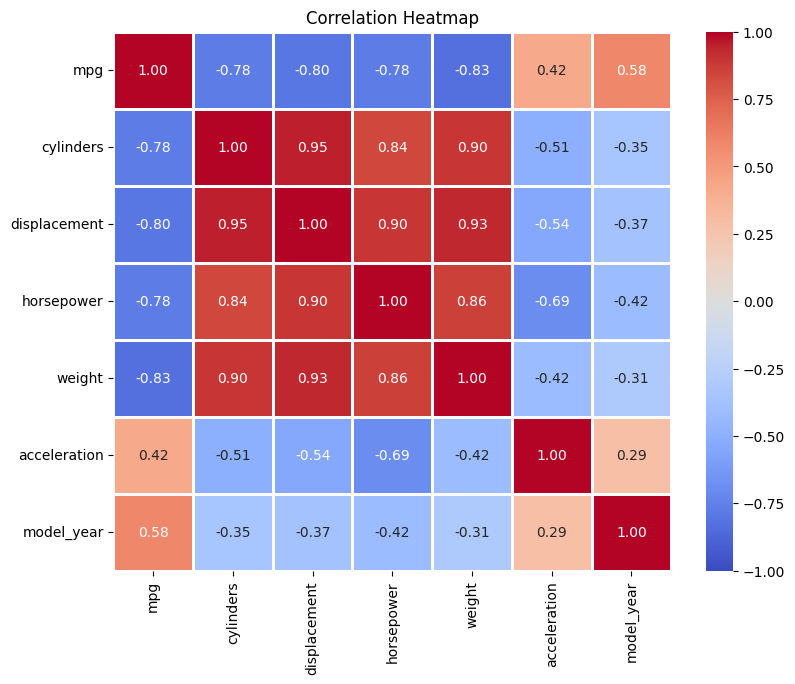

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('mpg')

# 왜 corr()로 행렬을 만드나요?
# → 숫자형 변수가 7개면, 비교 가능한 조합이 21개입니다.
#   하나씩 .corr()로 비교하면 21번 써야 합니다.
#   df.corr()는 모든 숫자형 변수 쌍의 상관계수를 한 번에 계산합니다.
#   numeric_only=True : 문자형 컬럼(origin, name)은 제외하고 계산
corr = df.corr(numeric_only=True)
print(corr.round(2))

# 왜 히트맵으로 그리나요?
# → 위에 출력된 숫자 표는 값이 너무 많아 한눈에 안 들어옵니다.
#   히트맵은 숫자를 색상으로 바꿔주므로, 진한 빨강/파랑만 찾으면 됩니다.
#   annot=True   : 색상과 함께 숫자도 표시
#   cmap='coolwarm' : 음의 상관은 파랑, 양의 상관은 빨강
#   vmin/vmax    : 색상 기준을 -1 ~ +1로 고정 (고정하지 않으면 데이터마다 색 기준이 달라져 비교가 어려움)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=1, vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

- 복잡해 보입니다.
- 자세히 보면 중복 데이터들이 있네요. 대칭되어있습니다.
- 불필요한데이터를 삭제해봅시다.

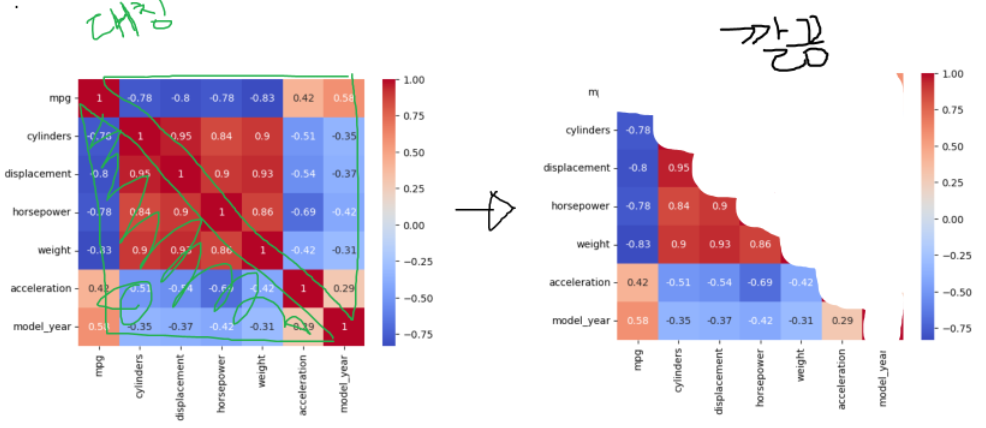

[[ True  True  True  True  True  True  True]
 [False  True  True  True  True  True  True]
 [False False  True  True  True  True  True]
 [False False False  True  True  True  True]
 [False False False False  True  True  True]
 [False False False False False  True  True]
 [False False False False False False  True]]


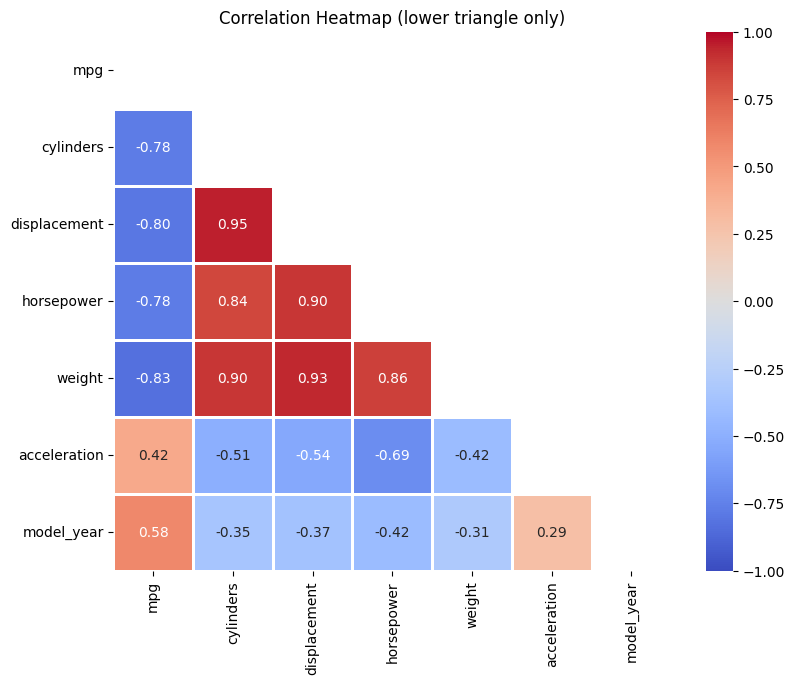

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('mpg')
corr = df.corr(numeric_only=True)

# 왜 삼각형으로 잘라내나요?
# → 위 히트맵은 대각선을 기준으로 위아래가 똑같은 값입니다.
#   (weight-mpg 상관계수 = mpg-weight 상관계수이므로 당연합니다)
#   절반은 중복이니 가려서 더 읽기 쉽게 만듭니다.
#   np.triu() : 대각선 '포함' 위쪽을 True로 만듭니다. → 대각선(자기 자신, 항상 1.0)도 함께 숨겨집니다.
#   대각선을 남기고 싶다면 np.triu(..., k=1) 로 바꿔보세요.
mask = np.triu(np.ones_like(corr, dtype=bool))
print(mask)  # True인 칸이 히트맵에서 숨겨집니다

# mask=mask : True인 칸은 숨기고, False인 칸(아래 삼각형)만 표시
plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=1, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (lower triangle only)')
plt.show()

- 아주 강력하게 상관관계를 보이는 것은 진한 파랑색과 진한 빨강으로 잘 표시가 되네요.
- 읽어보면 몇 가지가 보입니다.
  1. `model_year`가 올라갈수록 연비(`mpg`)가 올라갑니다. (약 **+0.58**) 해가 갈수록 연비가 개선된 것으로 보입니다.
  2. `model_year`와 `weight`는 약 **-0.31**입니다. 약한 음의 상관관계라, "해가 갈수록 차가 가벼워졌다"고 단정하기에는 근거가 부족합니다.
  3. 가속 시간(`acceleration`)은 `weight`(약 -0.42)보다 `horsepower`(약 **-0.69**)와 훨씬 강하게 묶여 있습니다.

> **✅ 아까 세운 가설, 검증 완료**
>
> 산점도에서 "무거운 차가 더 빨리 가속한다"는 이상한 결과를 봤습니다. 히트맵이 답을 줍니다.
> - `weight` ↔ `horsepower` 상관계수: 약 **+0.86** (무거운 차일수록 마력이 크다)
> - `horsepower` ↔ `acceleration` 상관계수: 약 **-0.69** (마력이 클수록 가속 시간이 짧다)
>
> 즉 진짜 원인은 무게가 아니라 **마력**이었습니다. 무게는 마력과 함께 움직였을 뿐입니다.
> 이것이 앞에서 말한 **"상관관계 ≠ 인과관계"**의 실제 사례입니다.

> **💡 히트맵을 읽는 순서 (실무 팁)**
>
> 1. 먼저 **가장 진한 칸**(절댓값 0.7 이상)만 찾습니다.
> 2. 그중 **예측하려는 목표 변수**와 연결된 칸을 봅니다. → 중요한 입력 변수 후보
> 3. **입력 변수끼리** 지나치게 진한 칸이 있는지 봅니다. → 같은 정보가 중복된 것일 수 있습니다.


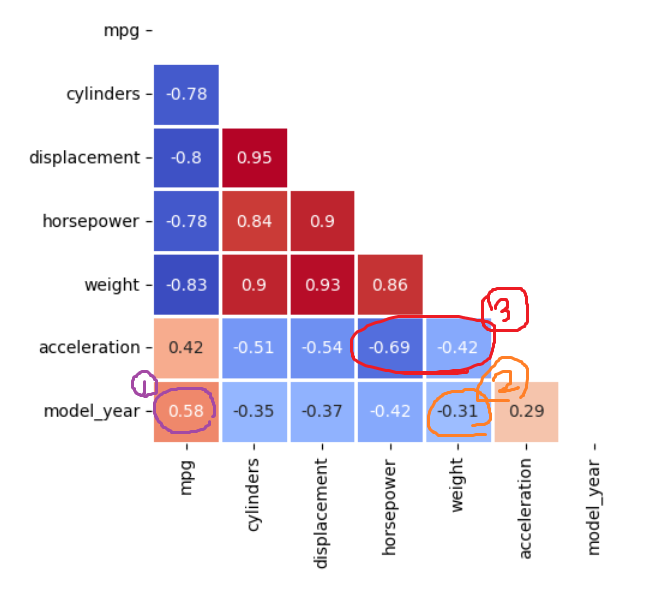

# 5. 분포(Distribution)

- 이 분포는 고등학교때 배운 개념입니다~ (기억이 잘 안날 확률이 더 높다고 생각합니다.)
- 이 개념을 복습하면서, 싸이킷런으로 데이터의 분포, 분산 정도를 확인해봅시다.

<br/>

### 분포가 뭔가요?

> **💡 분포를 한마디로?**
>
> **"어디에 값이 몰려있나?"**를 보여주는 **모양**입니다.
>
> 롯데월드에서 사람들이 어디에 몰렸는지 보고 싶으면? → 놀이기구별 대기 인원 분포를 보면 됩니다!
> - 범퍼카: 10명, 바이킹: 50명, 자이로드롭: 80명, 회전목마: 5명
> - 이걸 막대 그래프로 그리면 → 분포가 보이는 것!

- 분포의 정의는 **데이터가 퍼져있는 모양** 입니다.
- 분포를 확인하는 방법은, 값 마다 빈도수(Frequency)를 확인하면 한눈에 알 수 있습니다.

> **💡 히스토그램(Histogram)이란?**
>
> 데이터의 범위를 여러 구간(bin)으로 나누고, 각 구간에 몇 개의 데이터가 속하는지 **막대 그래프**로 그린 것입니다.
> - 장점: 데이터가 어디에 집중해있는지 직관적으로 파악
> - 이상치(다른 막대와 동떨어진 막대)도 쉽게 발견


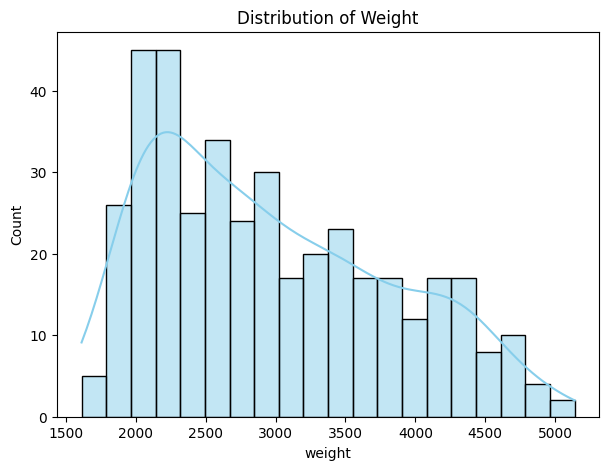

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('mpg')

# 왜 히스토그램을 그리나요?
# → 상관관계가 '변수 간의 관계'를 봤다면,
#   히스토그램은 '하나의 변수가 어떻게 생겼는지'를 봅니다.
#   값이 어디에 몰려있는지, 한쪽으로 쏠렸는지, 튀는 값은 없는지 확인합니다.
#   bins=20  : 데이터를 20개 구간으로 쪼개서 표시 (숫자를 바꿔가며 비교해 보세요)
#   kde=True : 막대 위에 부드러운 곡선을 함께 그려 전체 모양을 파악
plt.figure(figsize=(7, 5))
sns.histplot(df['weight'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Weight')
plt.show()

# 직접 해보기: bins를 5, 50으로 바꿔보세요.
# 같은 데이터인데도 그래프 모양이 꽤 달라 보입니다.
# → 히스토그램은 구간 개수에 따라 해석이 달라질 수 있다는 점을 기억하세요.

- 위 데이터를 보니, 차량 무게는 **2,000~2,300 파운드(약 900~1,050kg)** 구간에 가장 많이 몰려 있군요.

<br/>

### 분포의 오해! [중요]

- 분포는 통계량... 수치가 아닙니다. **모양**입니다.
- 수 하나로 분포 모양을 설명 못해요.
- 분포 모양을 설명하려면, 여러 통계 값으로 표현합니다. (아래는 수치로 표현되는 통계량 들입니다.)

> **💡 분포를 설명하는 통계량 5인방**
>
> | 통계량 | 의미 | 쉬운 비유 |
> |--------|------|----------|
> | 평균 | 중심이 어디인가 | 시소의 균형점 |
> | 분산 | 평균 주변으로 얼마나 퍼져있나 | 학생들이 선생님 주변에 얼마나 흩어져 있는지 |
> | 표준편차 | 퍼짐의 강도 | 분산에 루트(√)를 씌운 것 |
> | 왜도 | 좌우 어느 쪽으로 치우쳐있나 | 기우뚱한 정도 |
> | 첨도 | 가운데가 뾰족한가, 납작한가 | 산봉우리의 날카로움 |
>
> 이 5가지로도 분포를 정확히 설명할 수 없지만, 특징을 수치로 표현할 순 있습니다.


### [참고] AI에서 자주 사용하는 통계량은 --> 평균과 표준편차!
- 평균과 표준편차.. 이 두 가지를 가장 많이 씁니다.
- 어디에 쓰이는지 느낌만 알고 넘어갈게요.
  - 심하게 큰 값이 있으면, 작은 값을 가진 변수가 학습이 잘 안되거든요.
  - 입력 데이터를 특정 평균의 표준편차 값을 가진데이터로 스케일링하면 학습이 더 잘됩니다.  
    - 값의 범위를 좁히거나 늘리는 거죠.
  - 그래서 데이터 전처리 작업으로, 필수처럼 합니다.
    - 데이터를 특정 기준에 맞춰 스케일링 하는 개념을 "정규화" 라고 합니다.
    - 정규화 중에서 **평균 0, 표준편차 1** 으로 정규화하는 것을 **표준화** 라고 합니다.
- 표준화는 곧 다룰 겁니다. 이를 위해 분산에 대해 완벽히 이해해주세요.


# 6. 분산

> **💡 분산을 한마디로?**
>
> **"데이터가 평균에서 얼마나 흩어져 있는지"**를 숫자 하나로 나타낸 것입니다.

- 지금까지 분포가 뭔지 알아봤습니다. 이번엔 '분산'에 대해 얘기해보겠습니다.
  - 분포는 퍼져있는 모양이고, 어디에 쏠려있는지 눈으로 볼 수 있죠.
  - 분포를 수치로 설명하는 통계량 중 하나가 바로 **분산** 입니다.

- 분산은 평균 기준으로 얼마나 퍼져있는지를 수치로 나타냅니다.
  - AI 에서 평균, 표준편차.. 이렇게 2개를 많이쓴다고 했잖아요?
  - 표준편차를 분산으로 계산합니다. **분산에 루트(√)를 씌우면 바로 표준편차**예요.

> **💡 분산 → 표준편차 관계**
>
> ```
> 분산 = 오차²의 평균
> 표준편차 = √분산
> ```
> 왜 분산에 루트를 씌울까? 분산은 제곱한 값이라 단위가 달라지거든요.
> (점수²이 되어버림) 루트를 씌우면 원래 단위로 돌아옵니다.


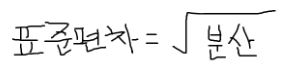

### 분산의 예시
- A반과 B반이 모두 평균이 80점 이라고 가정하겠습니다.
  - A 반 (총 3명) : 79점, 80점, 81점
  - B 반 (총 3명) : 70점, 80점, 90점

- A반은 분산이 작습니다. (평균 근처에 몰려있으니까)
- B반은 분산이 큽니다. (평균에서 멀리 퍼져있으니까)

### 분산 계산법
- 각 값에서 평균을 뺀 차이를 **제곱**해서 평균하면 됩니다.

> **💡 왜 제곱을 할까?**
>
> 0-2 챕터의 MSE에서 배운 것과 같은 이유입니다!
> - 양수/음수 오차가 상쇄되는 것을 방지
> - 큰 오차에 더 큰 가중치를 부여


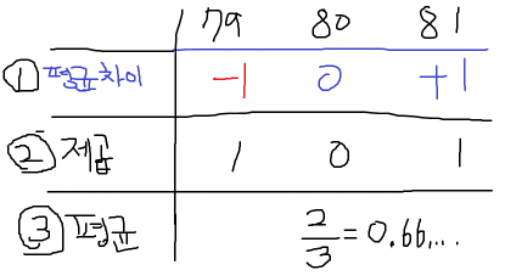

In [11]:
import numpy as np

# A반 : 79, 80, 81점 (평균 80)
# → 다들 비슷한 점수. 평균 주변에 모여 있음.
data = np.array([79, 80, 81])
print(type(data))

# 왜 분산을 구하나요?
# → 평균만 보면 두 반 모두 80점으로 같습니다.
#   하지만 '다들 비슷한 80점'과 '들쑥날쑥한 80점'은 완전히 다른 상황입니다.
#   분산은 이 차이를 숫자로 표현해줍니다. (작으면 모여 있고, 크면 흩어져 있음)
variance = np.var(data)
print(f'A반 분산: {variance:.4f}')  # 약 0.67 → 매우 작음 → 다들 비슷비슷

<class 'numpy.ndarray'>
A반 분산: 0.6667


- 이번엔 [70, 80, 90] 의 분산값을 구해보시죠.


In [12]:
import numpy as np
import pandas as pd

# B반 : 70, 80, 90점 (평균 80)
# → 점수 차이가 큼. 평균에서 멀리 퍼져 있음.
data = np.array([70, 80, 90])
variance = np.var(data)

# 같은 평균 80점인데, A반 분산(약 0.67)과 B반 분산(약 66.67)은 100배 차이입니다.
# → 분산을 보면 '같은 평균이라도 실제 상황이 얼마나 다른지' 알 수 있습니다.
#   이것이 AI에서 분산/표준편차를 중요하게 보는 이유입니다.
print(f'B반 분산: {variance:.4f}')  # 약 66.67 → 크다 → 실력 차이 심함

# ----------------------------------------------------------
# [자주 하는 질문] numpy와 pandas의 분산 값이 다릅니다!
# ----------------------------------------------------------
# 같은 데이터인데 결과가 다릅니다. 버그가 아니라 기본 설정 차이입니다.
#   np.var()          → ddof=0 (모집단 분산). 가진 데이터가 전부라고 가정
#   pd.Series.var()   → ddof=1 (표본 분산).   가진 데이터가 일부 표본이라고 가정
# 앞에서 df.describe()로 본 std도 ddof=1 기준입니다.
print()
print('numpy  분산(ddof=0):', round(np.var(data), 4))
print('pandas 분산(ddof=1):', round(pd.Series(data).var(), 4))
print('numpy에 ddof=1 지정:', round(np.var(data, ddof=1), 4))
print()
print('→ 데이터가 많아질수록 두 값의 차이는 거의 없어집니다. 지금은 3개뿐이라 차이가 커 보입니다.')

B반 분산: 66.6667

numpy  분산(ddof=0): 66.6667
pandas 분산(ddof=1): 100.0
numpy에 ddof=1 지정: 100.0

→ 데이터가 많아질수록 두 값의 차이는 거의 없어집니다. 지금은 3개뿐이라 차이가 커 보입니다.


- 정리하자면.. 분산값이 크면 평균에서 퍼져있는 정도가 큰것입니다.
- A반 분산 약 0.67 vs B반 분산 약 66.67 → B반이 **100배** 더 퍼져있다!


# 7. 한방에 EDA 를 하자! 한방 차트 - pairplot()
- EDA 할때 상관관계를 히트맵으로 볼 수 있었습니다.
  - 양의 상관관계 / 음의 상관관계 / 상관없는 변수를 구분할 수 있었죠.
- EDA 할때 어디에 값이 몰려있는지, 모양을 보고싶을 때 분포를 확인하면 됩니다.
  - 빈도수를 막대 차트로와 선으로 표현하면 분포(모양)을 확인할 수 있었죠.

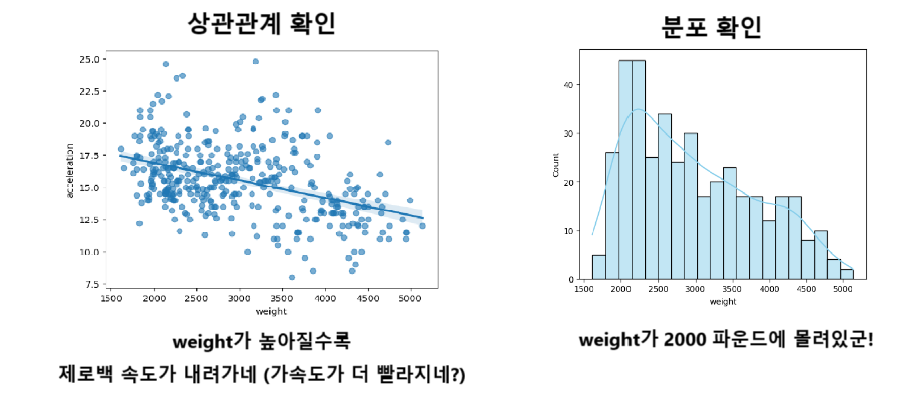

- 위 내용들을 한방에 볼 수 있는 plot이 있습니다. pairplot 입니다.
- 아래 데이터를 이해해보세요.

결측치 제거: 398행 → 392행 (6개 제외)


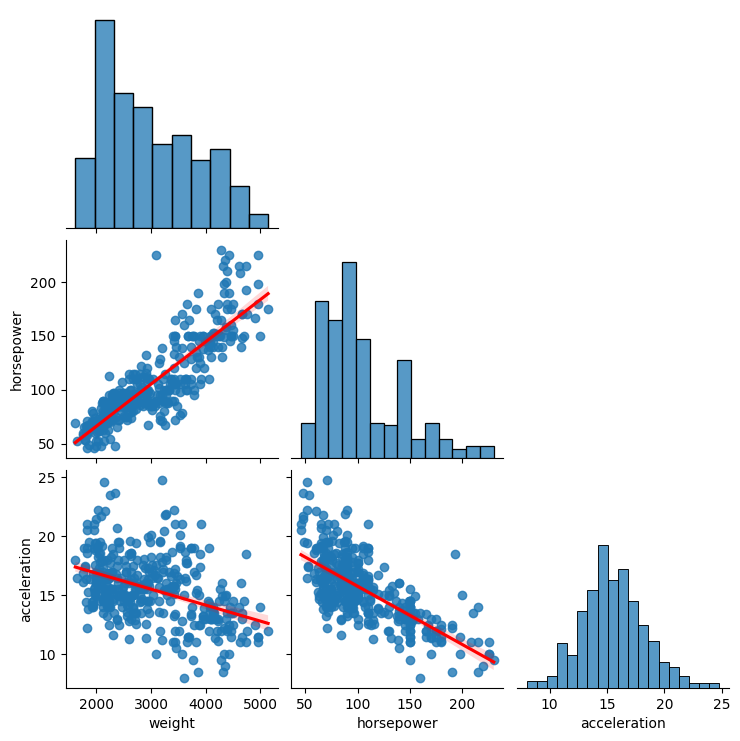

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('mpg')

# 왜 결측치를 먼저 제거하나요?
# → pairplot은 결측치가 있는 행을 조용히 빼고 그립니다. 에러는 나지 않습니다.
#   하지만 '몇 개가 빠진 채로 그려졌는지' 모르는 상태로 해석하면 위험합니다.
#   그래서 직접 명시적으로 제거하고, 몇 개가 빠졌는지 확인하고 넘어갑니다.
before = len(df)
df = df.dropna(subset=['horsepower'])
print(f'결측치 제거: {before}행 → {len(df)}행 ({before - len(df)}개 제외)')

# 왜 pairplot을 쓰나요?
# → 지금까지 산점도, 히스토그램, 히트맵을 따로따로 그렸습니다.
#   pairplot은 이것을 한 번에 보여줍니다.
#   대각선   = 각 변수의 분포(히스토그램)
#   나머지   = 변수 쌍의 산점도 + 추세선
#   corner=True : 중복되는 윗부분 숨김 (히트맵에서 삼각형으로 자른 것과 같은 이유)
#   kind='reg'  : 산점도에 추세선(빨간 선) 추가
#
# 주의: 변수 개수가 늘어나면 그림이 제곱으로 늘어나 계산이 느려집니다.
#       보통 10개를 넘기지 않고, 중요한 변수만 골라서 그립니다.
sns.pairplot(
    df[['weight', 'horsepower', 'acceleration']],
    corner=True,
    kind='reg',
    plot_kws={'line_kws': {'color': 'red'}}
)
plt.show()

# 8. EDA 끝!, 정리합시다.

- EDA는 데이터를 **이해하는** 과정입니다.
- 여기서 자주 헷갈리는 지점 하나를 짚고 갑니다.
  - 이상치와 결측치를 **확인하고, 원인을 추측하는 것** = EDA
  - 이상치와 결측치를 **제거하거나 다른 값으로 채우는 것** = 전처리(Preprocessing)

> **💡 그런데 앞에서는 EDA 순서에 "데이터 정제"가 있었는데요?**
>
> 맞습니다. 현장에서는 두 작업이 붙어서 돌아가기 때문에, **EDA를 넓게 정의할 때는 정제까지 포함**하기도 합니다.
> - 좁은 의미의 EDA = 보고 이해하기
> - 넓은 의미의 EDA = 보고 이해한 뒤, 발견한 문제를 고치는 것까지
>
> 어느 쪽이 맞고 틀린 게 아니라 **범위를 어디까지 잡느냐의 차이**입니다.
> 다만 시험이나 면접에서는 "EDA는 이해, 전처리는 수정"으로 구분해 답하면 안전합니다.

- 단순히 데이터를 출력해보는 것도 EDA이니, 시작하는 문턱은 아주 낮습니다.
- 이 수업을 통해 변수, 분포, 상관관계, 상관계수, 분산 같은 필수 통계 개념을 이해하는 것이 목표입니다.

> **📌 이 노트북에서 다루지 않은 것**
>
> 결측치를 실제로 채우거나 IQR 기준으로 이상치를 제거하는 **전처리 실습**은 본 과정 실습 노트북에서 다룹니다.
> 여기서는 "문제가 있다는 것을 발견하는 것"까지만 진행했습니다.


# 9. Scikit-learn 이란?
- 드디어 새로운 챕터로 넘어왔습니다.

> **💡 머신러닝 3대 라이브러리**
>
> | 라이브러리 | 특징 | 비유 |
> |-----------|------|------|
> | **Scikit-Learn** | 머신러닝 대표 (선형회귀, 로지스틱회귀, 클러스터링 등) | 만능 도구함 |
> | **TensorFlow** | 딥러닝 특화 (구글) | 전문 공작 기계 |
> | **PyTorch** | 딥러닝 특화 (메타, 코드가 간결) | 최신형 공작 기계 |

- 머신러닝 모델은 선형회귀, 로지스틱회귀, 클러스터링, 신경망 등 많거든요.
- 딥러닝은 신경망(Neural Network, NN)을 수십 층으로 딥~ 하게 만든 모델을 의미합니다.
- 다시 말하면.. 싸이킷 런은 머신러닝 Library / PyTorch는 딥러닝 Library 입니다.

# 10. Scikit-learn 기본 코드 이해 (선형회귀, 로지스틱회귀)

- 싸이킷런의 Hello world인 선형회귀 모델을 써봅시다.
- 싸이킷 런의 입력 데이터는 **2차원 행렬**로 입력 받습니다.
- 따라서 입력데이터 X를 2차원 행렬로 변경합니다.
  - reshape(n, 1) : 세로 n × 가로 1 사이즈로 행렬 형태 변경
  - n을 소스코드에서는 -1로 표현합니다.

> **💡 reshape(-1, 1)이란?**
>
> 1차원 배열을 **세로로 긴 2차원 행렬**로 바꾸는 것입니다.
> ```
> [1, 2, 3, 4]  →  [[1],
>                    [2],
>                    [3],
>                    [4]]
> ```
> -1은 "알아서 계산해줘"라는 뜻입니다. (데이터 개수에 맞게 자동 설정)


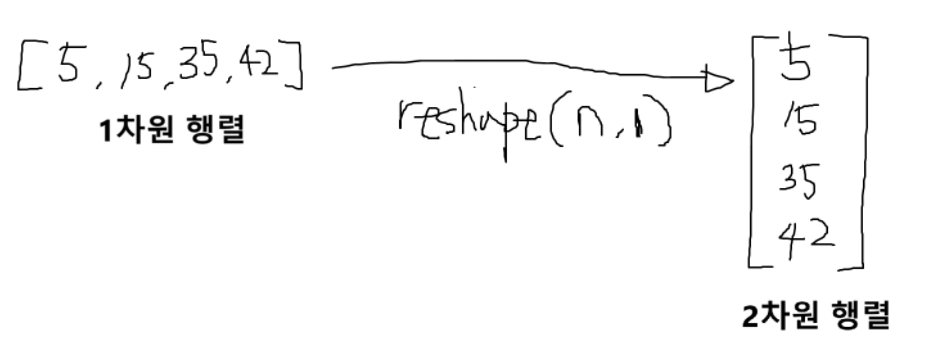

- Library를 쓰니까, 저번에 직접 구현했던 것 보다 코드가 확실히 간결합니다.

> **💡 Scikit-learn의 기본 패턴 (암기!)**
>
> ```python
> model = 모델클래스()     # 1단계: 모델 객체 생성
> model.fit(X, y)          # 2단계: 데이터로 학습
> y_hat = model.predict(X) # 3단계: 예측
> ```
> 어떤 모델이든 이 3단계 패턴은 동일합니다! (선형회귀, 로지스틱회귀, 신경망 등)


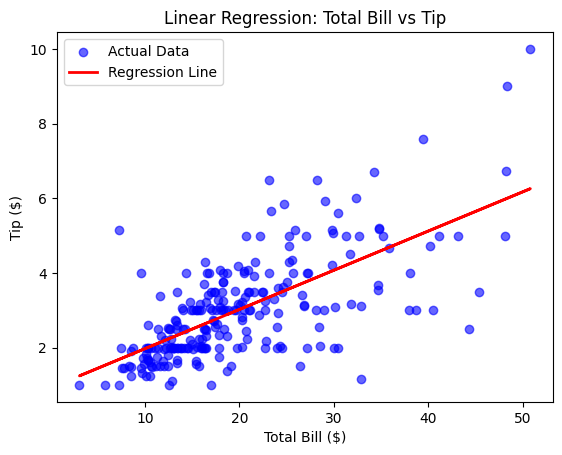

In [14]:
# 로컬에서는 설치 필요. 최초 1번 실행
#!pip install scikit-learn

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ========== 1. 데이터 준비 ==========
tips = sns.load_dataset('tips')

# 왜 reshape(-1, 1)을 하나요?
# → 싸이킷런은 입력(X)을 반드시 "2차원 행렬"로 받습니다.
#   지금 X는 [3.07, 10.34, ...] 같은 1차원 배열인데,
#   이걸 [[3.07], [10.34], ...] 처럼 세로로 긴 2차원으로 바꿔야 합니다.
#   왜 2차원? → 나중에 피쳐(입력 변수)가 여러 개가 되면 열이 늘어나야 하니까요.
#   (ex: [[식사금액, 인원수], [식사금액, 인원수], ...] ← 피쳐 2개)
X = tips['total_bill'].values.reshape(-1, 1)
y = tips['tip'].values  # 정답(y)은 1차원 그대로 OK

# ========== 2. 모델 생성 및 학습 ==========
# 왜 두 줄로 나뉘어 있나요?
# → 1) 빈 모델을 만들고 (아직 아무것도 모르는 상태)
#   2) fit()으로 데이터를 먹여서 학습시킵니다.
#   fit() 안에서 오차(MSE)를 가장 작게 만드는 a, b를 한 번에 계산합니다.
#   (0-2챕터의 정규방정식과 같은 원리이며, 실제 구현은 수치적으로 더 안정적인 방식을 씁니다)
model = LinearRegression()
model.fit(X, y)

# ========== 3. 예측 ==========
# 왜 학습에 쓴 데이터로 다시 예측하나요?
# → 지금은 "모델이 제대로 만들어졌는지" 확인하기 위해서입니다.
#   나중에는 학습에 안 쓴 새로운 데이터로 예측해야 진짜 평가가 됩니다. (뒤에서 배움)
y_hat = model.predict(X)

# ========== 4. 시각화 ==========
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X, y_hat, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Linear Regression: Total Bill vs Tip')
plt.legend()
plt.show()


- 이번엔 로지스틱 회귀입니다
- 저번에 직접 짰던 코드를 Library를 쓴 코드로 바꿔보겠습니다
- 특이한 점은 model.predict_proba( ) 호출 시 탈락확률과 합격확률이 동시에 함께 반환됩니다.
  - 예를들면 f(2시간) = [탈락확률 30%, 합격확률 70%] 이렇게요.
  - 차트는 합격확률만 그리기 위해 "합격확률"만 추출해서 선으로 그렸습니다.

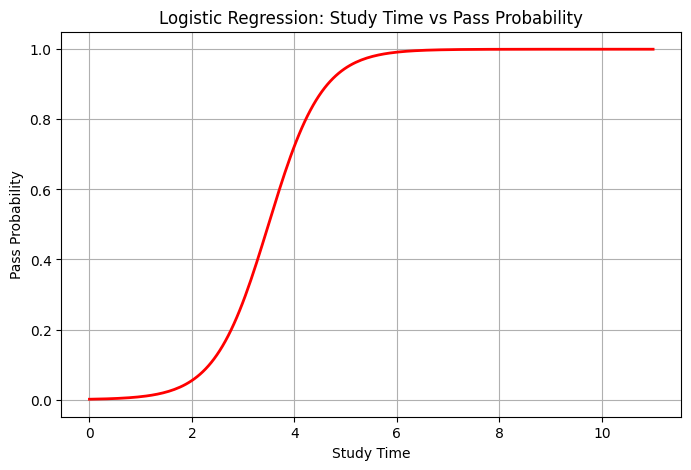

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 공부 시간 (입력값) - 왜 reshape(-1, 1)? → 싸이킷런 입력은 항상 2차원!
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10]).reshape(-1, 1)

# 합격 여부 (정답: 0=불합격, 1=합격)
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

# 왜 LogisticRegression을 쓰나요? (LinearRegression이 아니라)
# → 이 문제는 "합격이냐 불합격이냐"를 맞추는 분류 문제입니다.
#   LinearRegression은 숫자를 예측하고, LogisticRegression은 확률을 예측합니다.
#   0-2챕터에서 배운 sigmoid(ax+b) 를 내부적으로 사용합니다.
model = LogisticRegression()
model.fit(X, y)

# 왜 linspace로 새 데이터를 만드나요?
# → 학습 데이터는 1,2,3...10 같은 듬성듬성한 정수입니다.
#   부드러운 S자 곡선을 그리려면 0~11 사이를 200등분한 촘촘한 값이 필요합니다.
X_new = np.linspace(0, 11, 200).reshape(-1, 1)

# 왜 predict가 아니라 predict_proba를 쓰나요?
# → predict()는 0 또는 1만 반환합니다. (합격/불합격)
#   predict_proba()는 [불합격확률, 합격확률]을 반환합니다. (예: [0.3, 0.7])
#   S자 곡선을 그리려면 확률값이 필요하니까 predict_proba()를 씁니다.
y_hat = model.predict_proba(X_new)
y_hat = y_hat[:, 1]  # 왜 [:, 1]? → [불합격, 합격] 중 합격확률(두번째 열)만 추출

plt.figure(figsize=(8, 5))
plt.plot(X_new, y_hat, color='red', linewidth=2)
plt.xlabel('Study Time')
plt.ylabel('Pass Probability')
plt.grid(True)
plt.title('Logistic Regression: Study Time vs Pass Probability')
plt.show()


# 11. 표준화 (전처리)의 필요성
- 데이터를 **평균 0, 표준편차 1** 형태로 바꾸는 전처리입니다.

### 전처리 작업을 하는 첫 번째 이유 — 단위가 큰 변수가 판을 지배한다
- 아래와 같은 데이터가 있습니다.
  - 변수 1 : 키 160 ~ 190 cm 범위
  - 변수 2 : 손톱 길이 0.5cm ~ 1.5cm 범위
- 이 값을 그대로 학습하면, 숫자가 큰 **키가 손톱 길이를 묻어버립니다.**
- 그래서 두 변수를 **비슷한 크기의 범위**로 맞춰준 뒤 학습합니다.

### 전처리 작업을 하는 두 번째 이유 — "상대적인 위치"로 바꾸기 위해
- 원본 값은 그 자체로는 다른 변수와 비교할 수 없습니다.
- 표준화를 하면 각 값이 **"평균에서 표준편차 몇 개만큼 떨어져 있는가"** 로 바뀝니다. 이 값을 z값이라고 부릅니다.

> **💡 표준화 결과 읽는 법**
>
> ```
> z = (원래 값 - 평균) / 표준편차
> ```
> - `z = 0` → 딱 평균인 값
> - `z = +1` → 평균보다 표준편차 1개만큼 큰 값
> - `z = -2` → 평균보다 표준편차 2개만큼 작은 값
>
> 예시: 평균 70점, 표준편차 10점인 시험에서 90점을 받았다면 → `z = (90-70)/10 = +2`

> **⚠️ 아주 흔한 오해 3가지**
>
> 1. **"표준화하면 값이 0~1 사이가 된다"** → **아닙니다.**
>    표준화 결과에는 음수도 나오고, 이상치가 있으면 +3, -4 같은 값도 나옵니다. 범위에 상한/하한이 없습니다.
>    값을 0~1 사이로 눌러 담는 것은 **Min-Max 정규화**라는 다른 기법입니다.
> 2. **"표준화하면 백분위(상위 몇 %)로 바뀐다"** → **아닙니다.**
>    z값은 백분위가 아닙니다. 데이터가 정규분포에 가까울 때만 z값과 백분위가 대략 대응됩니다.
> 3. **"표준화하면 분포 모양이 예뻐진다"** → **아닙니다.**
>    중심과 폭만 옮길 뿐, **모양(왜도·첨도)은 그대로**입니다. 뒤 셀에서 표준화 전후 산점도를 직접 비교해 확인합니다.

### 표준화하면 뭐가 좋아지나요?
- 경사 하강법이 **더 빠르고 안정적으로 수렴**합니다. (더 "정확"해지는 것이 아니라, 더 "잘 굴러갑니다")
- 거리 기반 모델(KNN, SVM 등)에서 단위가 큰 변수가 결과를 독점하는 것을 막습니다.
- 규제(Regularization)를 쓸 때 모든 변수에 공평하게 적용됩니다.

> **📌 표준화가 필요 없는 모델도 있습니다**
>
> 결정 트리, 랜덤 포레스트, XGBoost 같은 트리 계열 모델은 값의 **크기**가 아니라 **순서**만 보기 때문에
> 스케일링을 해도 결과가 거의 바뀌지 않습니다. "무조건 표준화"가 아니라 **모델에 따라 판단**하세요.

### 꼭 평균 0, 표준편차 1이어야 하나요?
- 아니요. 특별한 이유가 없으면 표준화(평균 0, 표준편차 1)를 씁니다.
- 데이터 특성에 따라 Min-Max 정규화(0~1)나 RobustScaler(중앙값·IQR 기준) 같은 다른 방법을 쓰기도 합니다.

### 정규화와 표준화, 뭐가 다른가요?
- **정규화(Normalization)** : 값의 범위를 조정하는 행위 전체를 부르는 넓은 말입니다.
- **표준화(Standardization)** : 그중에서 "평균 0, 표준편차 1"로 맞추는 방법입니다.

> **⚠️ 용어 주의**
>
> 실무에서는 "정규화"라는 말을 **Min-Max 스케일링(0~1)만** 가리키는 뜻으로 쓰는 사람도 많습니다.
> 대화할 때는 "정규화"라고만 하지 말고 **"Min-Max로요? 표준화로요?"** 라고 되묻는 습관을 들이세요.



# 12. 표준화 구현하기
- 표준화는 StandardScaler 라는 클래스가 싸이킷런에 준비되어있습니다.
  - 표준화 하는 변환 수식이 있지만 생략합니다~! (교수님이 이론파트에서 설명해 주실껍니다.)

- 표준화를 통해 원본 데이터의 특성은 최대한 가져가면서, 학습이 더 잘되도록 값이 변경되는 것입니다.

[표준화 전] 평균 19.7859 / 표준편차 8.8842
[표준화 후] 평균 -0.0000 / 표준편차 1.0000
[표준화 후] 최솟값 -1.8815 / 최댓값 3.4921

→ 평균은 0, 표준편차는 1이 되었습니다.
→ 하지만 값의 범위는 0~1이 아닙니다. 음수도 나오고, 상한도 없습니다.


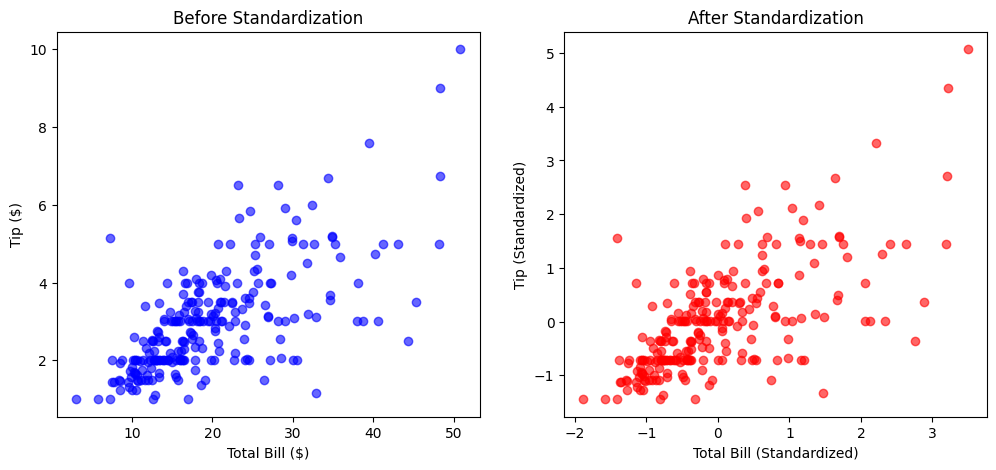

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

tips = sns.load_dataset('tips')

X = tips['total_bill'].values.reshape(-1, 1)
y = tips['tip'].values.reshape(-1, 1)

# 왜 StandardScaler 객체를 X용, y용으로 각각 만드나요?
# → X(식사금액)와 y(팁금액)는 평균과 표준편차가 다릅니다.
#   각각의 기준을 따로 기억해야 하므로 scaler도 따로 만듭니다.
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# 왜 fit()과 transform()이 따로인가요?
# → fit()       : 데이터를 보고 평균과 표준편차를 '계산해서 기억'합니다. (아직 변환 안 함)
#   transform() : 기억해 둔 평균/표준편차로 실제 데이터를 '변환'합니다.
#   왜 분리하나? → 나중에 테스트 데이터를 변환할 때 '학습 데이터의 기준'을 그대로 써야 하기 때문입니다.
scaler_X.fit(X)
scaler_y.fit(y)
X_std = scaler_X.transform(X)
y_std = scaler_y.transform(y)

# 표준화가 실제로 무슨 일을 했는지 숫자로 확인해봅시다.
print(f'[표준화 전] 평균 {X.mean():.4f} / 표준편차 {X.std():.4f}')
print(f'[표준화 후] 평균 {X_std.mean():.4f} / 표준편차 {X_std.std():.4f}')
print(f'[표준화 후] 최솟값 {X_std.min():.4f} / 최댓값 {X_std.max():.4f}')
print()
print('→ 평균은 0, 표준편차는 1이 되었습니다.')
print('→ 하지만 값의 범위는 0~1이 아닙니다. 음수도 나오고, 상한도 없습니다.')

# 왜 차트를 나란히 비교하나요?
# → 표준화 전후로 데이터의 '모양(분포)'은 그대로이고 '축의 숫자'만 바뀐 것을 확인하기 위해서입니다.
#   모양이 바뀌면 안 됩니다. 데이터 특성은 유지하면서 스케일만 조정하는 것이 표준화입니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X, y, color='blue', alpha=0.6)
axes[0].set_title('Before Standardization')
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Tip ($)')

axes[1].scatter(X_std, y_std, color='red', alpha=0.6)
axes[1].set_title('After Standardization')
axes[1].set_xlabel('Total Bill (Standardized)')
axes[1].set_ylabel('Tip (Standardized)')
plt.show()

# 13. 표준화한 데이터로 선형회귀하기
- 우리 목적은 다음과 같습니다.
  1. 데이터를 표준화 한 후에 학습합시다.
  2. 이후 예측을 해봅시다.

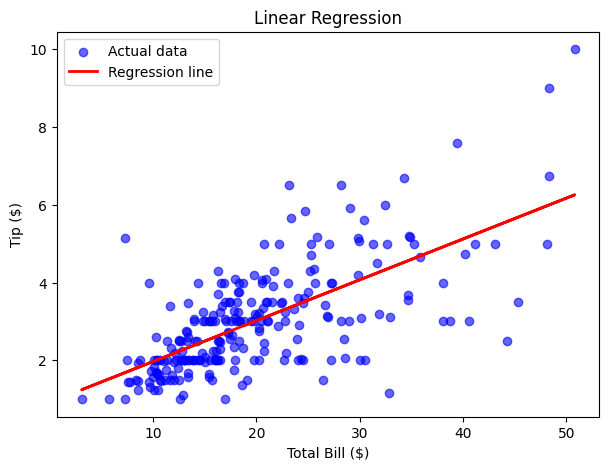

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

tips = sns.load_dataset('tips')

X = tips['total_bill'].values.reshape(-1, 1)
y = tips['tip'].values.reshape(-1, 1)

# ========== 1단계: 표준화 (왜? 학습 성능을 높이기 위해) ==========
scaler_X = StandardScaler()
scaler_y = StandardScaler()

scaler_X.fit(X)  # X의 평균, 표준편차 계산 (이 값은 나중에 테스트 데이터에도 그대로 재사용)
scaler_y.fit(y)
X_std = scaler_X.transform(X)
y_std = scaler_y.transform(y)

# ========== 2단계: 모델 학습 (표준화된 데이터로!) ==========
model = LinearRegression()
model.fit(X_std, y_std)  # 왜 원본이 아니라 표준화 데이터로? → 학습이 더 정확해지니까!

# ========== 3단계: 예측 ==========
y_hat_std = model.predict(X_std)
# 왜 예측값도 표준화된 상태인가요?
# → 표준화된 데이터로 학습했으니, 예측값도 표준화된 스케일로 나옵니다.
#   예측 팁이 0.3, -0.5 이런 값이면 사람이 이해할 수 없죠.
#   그래서 원래 달러 단위로 되돌려야 합니다!

# ========== 4단계: 원본 스케일로 복원 (왜? 사람이 이해하려고) ==========
y_hat = scaler_y.inverse_transform(y_hat_std)  # 표준화 ↔ 원본 변환

# 시각화 (원본 단위로 그래야 의미있는 차트가 됨)
plt.figure(figsize=(7, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Actual data')
plt.plot(X, y_hat, color='red', linewidth=2, label='Regression line')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Linear Regression')
plt.legend()
plt.show()

# ------------------------------------------------------------------
# [지금 코드의 한계 — 15장에서 다시 다룹니다]
# ------------------------------------------------------------------
# 지금은 데이터를 나누지 않고 전체에 scaler.fit()을 했습니다.
# 15장에서 배울 원칙대로 하면, 이것은 '테스트 데이터의 평균까지 미리 본' 것이라
# 데이터 유출(Data Leakage)에 해당합니다.
# 여기서는 표준화의 동작만 보기 위해 단순하게 작성했고,
# 올바른 순서(분리 → 학습 데이터로만 fit)는 15장에서 확인합니다.


- 이제 예측을 해봅시다.
- $50 어치 식사한 손님이 어느 정도 TIP을 낼지 예측해봅시다.
- 표준화를 한 데이터로 만든 모델이므로, 예측할때도 입력 데이터를 표준화 한 후 입력해야한다는 것을 잊지마세요.

In [18]:
# ※ 이 셀은 바로 위 셀(13장)에서 만든 model, scaler_X, scaler_y를 그대로 사용합니다.
#    위 셀을 먼저 실행하지 않으면 NameError가 납니다.

# $50어치 식사한 손님의 팁을 예측해봅시다.
new_bill = [[50]]

# 왜 테스트 값도 표준화해야 하나요?
# → 모델이 '표준화된 세계'에서 학습했기 때문입니다.
#   모델 입장에서 50이라는 원본 숫자는 학습할 때 본 적이 없는 스케일입니다.
#   학습할 때와 같은 기준(같은 평균, 같은 표준편차)으로 변환해줘야 올바르게 예측합니다.
#   ★ 핵심: 학습 때 쓴 scaler_X를 그대로 재사용해야 합니다.
#          (새 scaler를 만들어 fit하면 기준이 달라져 예측이 어긋납니다)
new_bill_std = scaler_X.transform(new_bill)
print(f'입력값 $50 → 표준화 후: {new_bill_std[0][0]:.4f}')

# 예측 (표준화된 입력 → 표준화된 출력)
pred_tip_std = model.predict(new_bill_std)

# 왜 다시 inverse_transform을 하나요?
# → 모델이 내놓은 예측값은 표준화된 값입니다. 사람이 읽을 수 없습니다.
#   원래 달러 단위로 되돌려야 의미를 알 수 있습니다.
pred_tip = scaler_y.inverse_transform(pred_tip_std)

print(f'$50 식사한 손님의 예상 TIP : ${pred_tip[0][0]:.2f}')

입력값 $50 → 표준화 후: 3.4009
$50 식사한 손님의 예상 TIP : $6.17


# 14. 과적합과 과소적합

> **💡 모델 평가 전에 꼭 알아야 할 개념!**
>
> 모델이 데이터를 학습하면 자동으로 좋은 모델이 되는 걸까요? **아닙니다!**
> 학습을 너무 많이 해도, 너무 적게 해도 문제가 됩니다.

### 과적합(Overfitting)
- 모델이 학습 데이터에만 **너무 과하게** 최적화되어, 새로운 데이터에서 성능이 나빠지는 현상
- 데이터의 중요한 패턴뿐만 아니라, **사소한 잡음(noise)까지 전부 외워버린** 상태

> **💡 과적합의 비유: 족보만 외운 학생**
>
> - 모의고사(학습 데이터) 문제와 답을 통째로 외움 → 모의고사 100점!
> - 하지만 수능(새 데이터)에서 처음 보는 문제가 나오면? → 멘붕...
> - 문제의 **패턴(풀이법)**을 이해한 게 아니라, **답을 외운 것**이라 응용이 안 됩니다.

### 과소적합(Underfitting)
- 모델이 **너무 단순해서** 학습 데이터의 핵심 패턴조차 제대로 학습하지 못한 상태
- 학습 데이터에서도 성능이 낮고, 테스트 데이터에서도 성능이 낮음

> **💡 과소적합의 비유: 공부를 안 한 학생**
>
> - 교과서를 훑어만 보고 시험을 봄 → 모의고사도 수능도 다 못 봄
> - 기본적인 공식(패턴)조차 익히지 못한 상태

> **📝 핵심 정리**
>
> | 상태 | 학습 데이터 성능 | 새 데이터 성능 | 비유 |
> |------|:---:|:---:|------|
> | 과소적합 | ❌ 낮음 | ❌ 낮음 | 공부를 안 한 학생 |
> | **적절한 학습** | ✅ 높음 | ✅ 높음 | **풀이법을 이해한 학생** |
> | 과적합 | ✅ 매우 높음 | ❌ 낮음 | 족보만 외운 학생 |
>
> 우리의 목표: **적절한 학습** 상태의 모델을 만드는 것!
> → 이를 확인하려면 **모델 평가**가 필수입니다.


# 15. 모델평가하기
- 선형회귀를 생각해보면 y = ax + b 에서, MSE가 가장 낮은 a, b 를 찾는 노력을 해왔습니다.
- 이렇게 완성된 모델이 **처음보는 데이터에 얼마나 예측을 잘하는지?** 평가를 하는 여러가지 방법이 있습니다.

> **💡 모델 평가는 왜 하나요?**
>
> 단순히 "어떤 모델이 더 좋은가"를 가리기 위함만이 아닙니다.
> - **학습 도중 중간 평가**를 해서, 학습 방법을 조율하기 위함입니다.
> - 비유: 학원 6개 다니면서 공부 중인 우리 아이, "중간고사" 후에 학원을 조정하는 것처럼요.
> - **과적합을 감지**하기 위함입니다. (학습 데이터에서는 좋은데 새 데이터에서 나쁘면 과적합!)


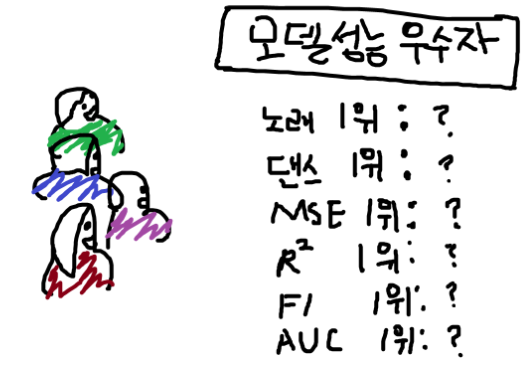

### 평가를 위해 데이터를 나누는 방법

- 우리 실습에서는 데이터셋을 몽땅 학습용으로 사용했습니다.
- 평가를 하려면, **학습에 사용하지 않은 데이터**로 평가를 해야합니다.

> **💡 데이터를 왜 나눠야 하나요?**
>
> 시험에 비유하면:
> - 같은 문제로 공부하고, 같은 문제로 시험보면 → 당연히 100점 (의미 없음)
> - **처음 보는 문제**로 시험봐야 → 진짜 실력을 알 수 있음
>
> 그래서 데이터를 **학습용**과 **시험용**으로 나눕니다!

- 일반적인 AI 학습에서는 전체 데이터를 3개로 나누는 것이 일반적입니다.
  - **Train Set** (학습용, 약 80%): 모델을 학습시키는 데이터
  - **Validation Set** (검증용, 약 10%): 학습 중간 평가용. 하이퍼파라미터 조율에 사용
  - **Test Set** (시험용, 약 10%): 최종 평가. **단 한 번만** 사용!

> **⚠️ 주의: 데이터 유출(Data Leakage)**
>
> Test 데이터로 자꾸 성능을 확인하며 모델을 수정하면, **수능 시험지를 미리 훔쳐보고 공부한 것**과 같습니다. 이것이 바로 **데이터 유출**입니다. Test는 정말 마지막에 딱 한 번만 사용해야 합니다!


### 싸이킷 런으로 데이터 나누기
- 선형회귀에서는 Validation Set 까지 필요하진 않습니다.
  - 나중에 신경망 모델 에서 필요하긴합니다.
- 간단히 싸이킷 런으로 Train Set과 Test Set을 분리하는 방법을 알아 봅시다.
  - 싸이킷런의 **train_test_split** 함수를 사용합니다.

In [19]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

tips = sns.load_dataset('tips')
X = tips['total_bill'].values
y = tips['tip'].values

print(f'원본 개수 : {X.size}개')

# 왜 데이터를 나누나요?
# → 같은 문제로 공부하고, 같은 문제로 시험보면 "진짜 실력"을 모릅니다.
#   80%는 공부(학습)용, 20%는 시험(평가)용으로 분리해야
#   "처음 보는 데이터에서도 잘 맞추는지" 확인할 수 있습니다.
#
# 왜 random_state=42인가요?
# → 데이터를 "랜덤으로 섞어서" 나누는데,
#   random_state를 고정하면 실행할 때마다 같은 방식으로 나뉩니다.
#   이래야 결과를 재현할 수 있어요. (42가 아니라 아무 숫자나 OK)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'\n[분할 후] Train 데이터 수 : {X_train.size}개 (80%)')
print(f'[분할 후] Test 데이터 수 : {X_test.size}개 (20%)')

# 직접 해보기: random_state를 42에서 0으로 바꾸고 다시 실행해 보세요.
# 개수는 같지만, 어떤 데이터가 Train/Test로 갔는지는 완전히 달라집니다.


원본 개수 : 244개

[분할 후] Train 데이터 수 : 195개 (80%)
[분할 후] Test 데이터 수 : 49개 (20%)


- 나중을 위해서 한번 3개로 분리를 해봅시다.
- Train = 80%, Validation = 10%, Test = 10%

In [20]:
import seaborn as sns
from sklearn.model_selection import train_test_split

tips = sns.load_dataset('tips')
X = tips['total_bill'].values
y = tips['tip'].values

print(f'원본 개수 : {X.size}개')

# 왜 3개로 나누나요? (2개가 아니라)
# → Train: 공부용 / Test: 최종 수능
#   그런데 수능 보기 전에 "모의고사"도 봐야 하잖아요?
#   Validation = 모의고사. 학습 도중에 중간 점검하는 용도입니다.
#   모의고사 결과를 보고 "학습률을 바꿀까? 학습을 멈출까?" 판단합니다.

# 1차 분할 : Train(80%) vs 나머지(20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# 왜 2번 나누나요? (train_test_split은 2개로만 나눌 수 있어서!)
# 2차 분할 : 나머지(20%)를 다시 반반 → Validation(10%) + Test(10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print()
print(f'[분할 후] Train 데이터 수 : {X_train.size}개 (약 80%)')
print(f'[분할 후] Validation 데이터 수 : {X_val.size}개 (약 10%)')
print(f'[분할 후] Test 데이터 수 : {X_test.size}개 (약 10%)')


원본 개수 : 244개

[분할 후] Train 데이터 수 : 195개 (약 80%)
[분할 후] Validation 데이터 수 : 24개 (약 10%)
[분할 후] Test 데이터 수 : 25개 (약 10%)


### 선형회귀 모델에서 대표적인 평가지표

> **💡 선형회귀 평가지표 2가지**
>
> | 지표 | 의미 | 좋은 값 |
> |------|------|--------|
> | **MSE** | 예측값과 실제값 오차의 제곱 평균 | **0에 가까울수록** 좋음 |
> | **R² (결정계수)** | 모델이 데이터 흐름을 얼마나 잘 설명하는지 | **1에 가까울수록** 좋음 |
>
> MSE는 0-2 챕터에서 배웠죠? 모델 평가에도 그대로 쓸 수 있습니다!


In [21]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

tips = sns.load_dataset('tips')
X = tips['total_bill'].values.reshape(-1, 1)
y = tips['tip'].values

# 왜 데이터를 먼저 나누고, 그 다음에 학습하나요?
# → 나누기 전에 학습하면 모델이 Test 데이터까지 이미 본 상태가 됩니다.
#   시험 문제를 미리 보고 공부한 것과 같습니다. (데이터 유출)
#   반드시 '데이터 분리 → Train으로만 학습 → Test로 평가' 순서를 지킵니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train 데이터로만 학습 (Test 데이터는 건드리지 않습니다)
model = LinearRegression()
model.fit(X_train, y_train)

# 왜 두 가지 지표를 모두 보나요?
# → MSE : 평균적으로 얼마나 틀렸는지 (0에 가까울수록 좋음)
#   R²  : 데이터의 흐름을 얼마나 잘 설명하는지 (1에 가까울수록 좋음)
#   하나만 보면 놓치는 부분이 있어서 여러 지표를 함께 봅니다.
#
# 왜 Train 점수도 같이 구하나요?
# → 14장에서 배운 과적합/과소적합을 판단하려면 두 점수를 '비교'해야 하기 때문입니다.
#   Test 점수만 보면 그 숫자가 좋은지 나쁜지 판단할 기준이 없습니다.
train_mse = mean_squared_error(y_train, model.predict(X_train))
train_r2 = r2_score(y_train, model.predict(X_train))
test_mse = mean_squared_error(y_test, model.predict(X_test))
test_r2 = r2_score(y_test, model.predict(X_test))

print(f'[Train] MSE {train_mse:.4f} / R² {train_r2:.4f}')
print(f'[Test ] MSE {test_mse:.4f} / R² {test_r2:.4f}')
print()
print('판단 기준')
print('  Train은 높고 Test가 크게 낮다  → 과적합 (족보만 외운 상태)')
print('  Train도 낮고 Test도 낮다       → 과소적합 (공부를 안 한 상태)')
print('  두 점수가 비슷하다             → 일단 정상 범위')
print()
print('참고: 지금은 Test 점수가 Train보다 오히려 높게 나옵니다.')
print('      Test가 49개뿐이라, 어쩌다 예측하기 쉬운 데이터가 몰린 것입니다.')
print('      데이터가 적을수록 이런 요동이 큽니다. 점수 하나를 그대로 믿으면 안 되는 이유입니다.')

[Train] MSE 1.1561 / R² 0.4310
[Test ] MSE 0.5688 / R² 0.5449

판단 기준
  Train은 높고 Test가 크게 낮다  → 과적합 (족보만 외운 상태)
  Train도 낮고 Test도 낮다       → 과소적합 (공부를 안 한 상태)
  두 점수가 비슷하다             → 일단 정상 범위

참고: 지금은 Test 점수가 Train보다 오히려 높게 나옵니다.
      Test가 49개뿐이라, 어쩌다 예측하기 쉬운 데이터가 몰린 것입니다.
      데이터가 적을수록 이런 요동이 큽니다. 점수 하나를 그대로 믿으면 안 되는 이유입니다.


### 로지스틱 회귀에서 대표적인 평가 지표

> **💡 분류 모델 평가지표 3가지**
>
> | 지표 | 의미 | 좋은 값 | 비유 |
> |------|------|--------|------|
> | **Accuracy** (정확도) | 전체 중 맞춘 비율 | 1에 가까울수록 | 전체 시험 점수 |
> | **F1-Score** | 정밀도와 재현율의 조화 평균 | 1에 가까울수록 | 균형 잡힌 실력 |
> | **AUC** (ROC-AUC) | 0과 1을 얼마나 잘 구분하는지 | 1에 가까울수록 | 구분 능력 |

- **Accuracy(정확도)**: 가장 직관적이지만, 데이터가 불균형하면 믿을 수 없음

> **💡 정확도만 믿으면 안 되는 이유**
>
> 100명 중 정상 99명, 암 환자 1명인 데이터에서...
> 모든 사람을 "정상"이라고 예측하는 바보 모델 → 정확도 **99%**!
> 하지만 정작 찾아야 할 암 환자 1명을 놓쳤으므로 **쓸모없는 모델**입니다.
>
> 이런 경우 **F1-Score**가 더 신뢰할 수 있는 지표입니다.

- **F1-Score**: 정밀도(Precision)와 재현율(Recall)의 조화 평균
  - 정밀도: 모델이 "1(양성)"이라고 예측한 것 중 진짜 1인 비율
  - 재현율: 실제 1인 것 중에서 모델이 1이라고 찾아낸 비율
- **AUC**: 모델이 0과 1을 잘 구분하는 정도 (면적 기반)
- 상세한 내용은 교수님 이론 강의에서 다룹니다.


In [22]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# 10장에서 쓴 것과 같은 데이터입니다. (공부 시간 → 합격 여부)
X = np.array([1,2,3,4,5,6,2,3,4,5,6,7,1,2,3,4,5,6,7,8,2,3,4,5,6,7,8,9,10]).reshape(-1, 1)
y = np.array([0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1])

# 왜 stratify=y 를 넣나요? (분류 문제에서는 사실상 필수)
# → 데이터가 29개뿐이라 그냥 무작위로 나누면,
#   운이 나쁘면 Test에 합격(1)만 들어가는 일이 생깁니다.
#   그러면 F1이나 AUC 계산이 아예 불가능하거나 이상한 값이 나옵니다.
#   stratify=y 는 원본의 합격/불합격 비율을 Train과 Test에 똑같이 유지해줍니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
print(f'Train {len(y_train)}개 / Test {len(y_test)}개')
print(f'Test 정답 구성 → 불합격 {(y_test == 0).sum()}개, 합격 {(y_test == 1).sum()}개')
print()

model = LogisticRegression()
model.fit(X_train, y_train)

# 왜 predict와 predict_proba를 둘 다 쓰나요?
# → predict()       : 0 또는 1로 확정 판단 → Accuracy, F1 계산에 사용
#   predict_proba() : 확률값(0.0~1.0)    → AUC 계산에는 확률값이 필요
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]  # 합격 확률만 추출

# 왜 평가 지표가 3개나 필요한가요?
# → Accuracy : 전체 중 맞춘 비율 (직관적이지만 데이터가 불균형하면 속기 쉬움)
#   F1-Score : 정밀도와 재현율의 균형 (불균형 데이터에서 더 신뢰할 수 있음)
#   AUC      : 0과 1을 얼마나 잘 구분하는지에 대한 종합 점수
#   하나만 보면 모델의 약점을 놓칠 수 있어 여러 각도에서 평가합니다.
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy : {acc:.4f}')
print(f'F1-score : {f1:.4f}')
print(f'AUC      : {auc:.4f}')

Train 20개 / Test 9개
Test 정답 구성 → 불합격 3개, 합격 6개

Accuracy : 1.0000
F1-score : 1.0000
AUC      : 1.0000


> **💡 점수가 전부 1.0으로 나왔습니다. 이상한 건가요?**
>
> 이상한 것이 아니라, **데이터가 너무 쉬워서** 그렇습니다.
> - 데이터가 29개뿐이고, "공부 시간이 길면 합격"이라는 규칙이 거의 예외 없이 성립합니다.
> - 이런 장난감 데이터에서는 만점이 자주 나옵니다.
>
> **실제 데이터에서 이런 만점이 나왔다면 반드시 의심하세요.**
> - 데이터 유출이 있었는지 (정답이 입력 변수에 섞여 들어간 경우)
> - Test 데이터가 너무 적어서 우연히 다 맞은 것은 아닌지
> - 학습 데이터와 테스트 데이터가 중복되지는 않았는지
>
> **직접 해보기**
> 1. `stratify=y`를 빼고 실행해 보세요. Test 구성이 어떻게 달라지나요?
> 2. `random_state`를 여러 값으로 바꿔가며 점수가 얼마나 흔들리는지 보세요.
>    → 데이터가 적을수록 점수가 크게 요동칩니다. 이 문제를 해결하는 방법이 **교차 검증**이며, 다음 실습에서 다룹니다.


# 16. 끝으로
- 수고 많으셨습니다!
- 이 수업에서는 EDA 분석을 하면서, 동시에 통계 기본 지식을 다루었습니다.
- 또한 싸이킷런 Library를 사용해보면서, 표준화와 모델 평가에 대한 기본 지식을 다루었습니다.
- 이 지식은 앞으로 **딥러닝**을 배울 때 기반 지식이 될 것입니다.

> **📝 이 챕터에서 배운 전체 핵심 정리**
>
> **EDA (탐색적 데이터 분석)**
> - 데이터를 이해하고 분석하는 모든 과정
> - 핵심 도구: df.info(), df.describe(), 히트맵, 히스토그램, pairplot
> - 상관관계 ≠ 인과관계
>
> **통계 기초**
> - 분포 = 데이터가 퍼져있는 모양
> - 분산 = 평균에서 얼마나 흩어져있는지 (숫자)
> - 표준편차 = √분산 (원래 단위로 복원)
>
> **Scikit-learn**
> - 3단계 패턴: 생성 → fit(학습) → predict(예측)
> - 표준화: 평균 0, 표준편차 1로 변환 (학습 성능 향상)
> - 데이터 분리: Train / Validation / Test
>
> **모델 평가**
> - 과적합: 학습 데이터에만 과하게 맞춤 (족보 외우기)
> - 선형회귀: MSE, R²
> - 로지스틱회귀: Accuracy, F1-Score, AUC|


---

## ✅ 스스로 점검하기

아래 질문에 **자기 말로** 답할 수 있으면 이 챕터를 이해한 것입니다.
막히는 항목이 있으면 괄호 안의 장으로 돌아가세요.

**EDA**
- [ ] `df.info()`와 `df.describe()`는 각각 무엇을 알려주나요? (2장)
- [ ] 결측치와 이상치는 어떻게 다르고, 어디서 발견할 수 있나요? (2장)
- [ ] 상관계수가 -0.8이면 두 변수는 어떤 관계인가요? (3장)
- [ ] "무거운 차가 더 빨리 가속한다"는 결과가 나왔을 때, 무엇을 의심해야 하나요? (3~4장)
- [ ] 히스토그램에서 `bins`를 바꾸면 왜 해석이 달라질 수 있나요? (5장)

**통계 기초**
- [ ] 분포와 분산의 차이는 무엇인가요? (5~6장)
- [ ] 분산에 왜 루트를 씌워 표준편차를 만드나요? (6장)
- [ ] `np.var()`와 `pandas`의 `.var()` 결과가 다른 이유는 무엇인가요? (6장)

**Scikit-learn**
- [ ] 싸이킷런의 3단계 패턴은 무엇인가요? (10장)
- [ ] `reshape(-1, 1)`은 왜 필요한가요? (10장)
- [ ] 표준화 결과의 값 범위는 0~1인가요? (11장)
- [ ] `fit()`과 `transform()`을 왜 분리해서 쓰나요? (12장)
- [ ] 테스트 데이터에 `fit()`을 하면 왜 안 되나요? (12장, 15장)

**모델 평가**
- [ ] 과적합인지 어떻게 판단하나요? (14장, 15장)
- [ ] Validation Set은 왜 따로 두나요? (15장)
- [ ] 정확도 99%인데 쓸모없는 모델이 나올 수 있는 이유는? (15장)

---

## 다음 시간 예고

이번 시간에는 데이터를 **눈으로 이해하는 것**까지 했습니다.
다음 실습에서는 여기서 발견한 문제를 **실제로 고치고**, 분류 모델을 끝까지 만들어 봅니다.

- 결측치 채우기 / IQR 기준 이상치 제거 (전처리)
- `stratify` 옵션으로 클래스 비율을 유지한 데이터 분리
- 혼동 행렬(Confusion Matrix)로 모델이 어떤 실수를 했는지 해부하기
- 교차 검증(Cross-Validation)으로 점수를 신뢰할 수 있는지 확인하기
- PCA(차원 축소)와 K-Means(군집화)
